### Importación de datos



In [20]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [7]:
ingresos = {
    "Tienda 1": tienda["Precio"].sum(),
    "Tienda 2": tienda2["Precio"].sum(),
    "Tienda 3": tienda3["Precio"].sum(),
    "Tienda 4": tienda4["Precio"].sum()
}

In [8]:
ingresos


{'Tienda 1': np.float64(1150880400.0),
 'Tienda 2': np.float64(1116343500.0),
 'Tienda 3': np.float64(1098019600.0),
 'Tienda 4': np.float64(1038375700.0)}

# 2. Ventas por categoría

In [9]:
ventas_cat_t1 = tienda.groupby("Categoría del Producto")["Producto"].count()
ventas_cat_t2 = tienda2.groupby("Categoría del Producto")["Producto"].count()
ventas_cat_t3 = tienda3.groupby("Categoría del Producto")["Producto"].count()
ventas_cat_t4 = tienda4.groupby("Categoría del Producto")["Producto"].count()

In [10]:

print("Tienda 1:\n", ventas_cat_t1.sort_values(ascending=False))
print("\nTienda 2:\n", ventas_cat_t2.sort_values(ascending=False))
print("\nTienda 3:\n", ventas_cat_t3.sort_values(ascending=False))
print("\nTienda 4:\n", ventas_cat_t4.sort_values(ascending=False))


Tienda 1:
 Categoría del Producto
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171
Name: Producto, dtype: int64

Tienda 2:
 Categoría del Producto
Muebles                    442
Electrónicos               422
Juguetes                   313
Electrodomésticos          305
Deportes y diversión       275
Instrumentos musicales     224
Libros                     197
Artículos para el hogar    181
Name: Producto, dtype: int64

Tienda 3:
 Categoría del Producto
Muebles                    499
Electrónicos               451
Juguetes                   315
Electrodomésticos          278
Deportes y diversión       277
Libros                     185
Artículos para el hogar    177
Instrumentos musicales     177
Name: Producto, dtype: int64

Tienda 4:
 Categoría del Producto
Muebles                    480

# 3. Calificación promedio de la tienda


In [11]:
calificaciones = {
    "Tienda 1": tienda["Calificación"].mean(),
    "Tienda 2": tienda2["Calificación"].mean(),
    "Tienda 3": tienda3["Calificación"].mean(),
    "Tienda 4": tienda4["Calificación"].mean()
}

In [12]:
calificaciones

{'Tienda 1': np.float64(3.976685036032217),
 'Tienda 2': np.float64(4.037303942348453),
 'Tienda 3': np.float64(4.048325561678677),
 'Tienda 4': np.float64(3.9957591178965224)}

# 4. Productos más y menos vendidos

In [21]:
def resumen_productos(df, nombre):
    ventas = df["Producto"].value_counts()
    mas_vendido = ventas.idxmax(), ventas.max()
    menos_vendido = ventas.idxmin(), ventas.min()
    print(f"{nombre} - más vendido: {mas_vendido}")
    print(f"{nombre} - menos vendido: {menos_vendido}\n")
    ventas.plot(kind="bar", figsize=(10,4), title=f"Ventas por producto - {nombre}")
    plt.xlabel("Producto")
    plt.ylabel("Cantidad de ventas")
    plt.tight_layout()
    plt.show()




Tienda 1 - más vendido: ('Microondas', 60)
Tienda 1 - menos vendido: ('Auriculares con micrófono', 33)



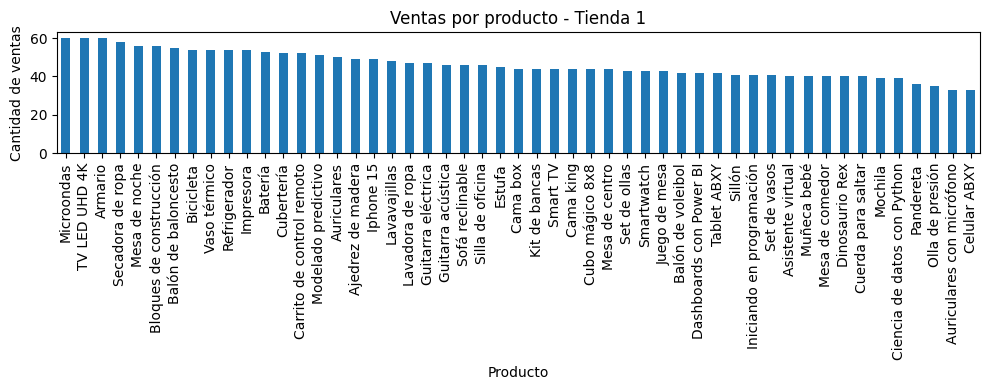

Tienda 2 - más vendido: ('Iniciando en programación', 65)
Tienda 2 - menos vendido: ('Juego de mesa', 32)



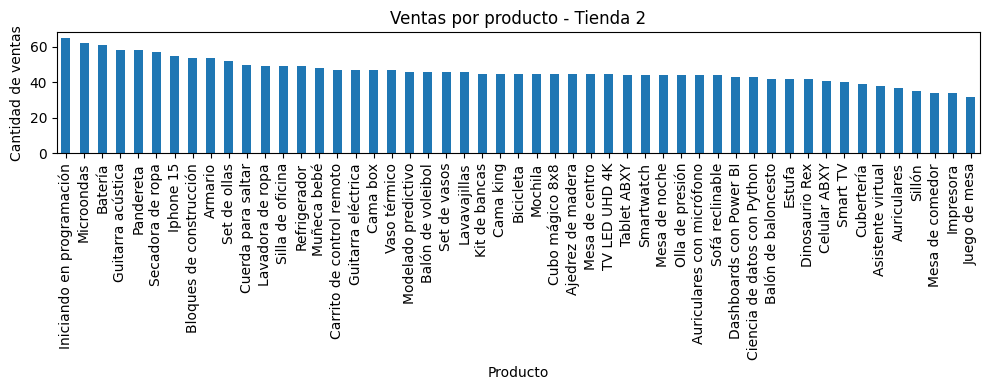

Tienda 3 - más vendido: ('Kit de bancas', 57)
Tienda 3 - menos vendido: ('Bloques de construcción', 35)



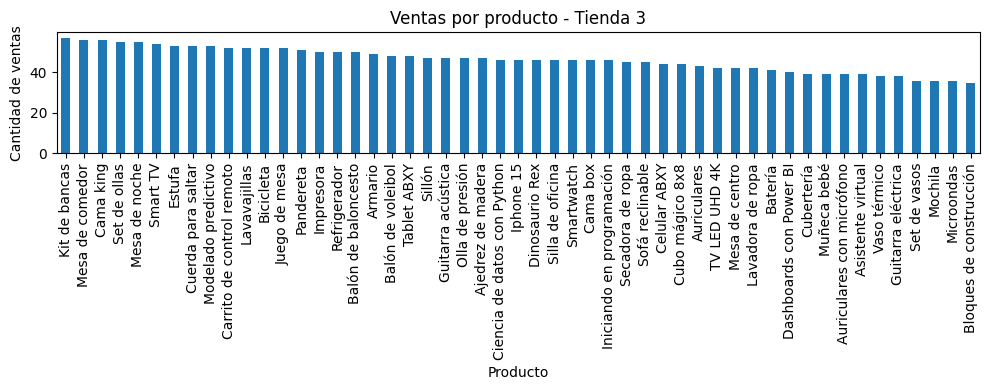

Tienda 4 - más vendido: ('Cama box', 62)
Tienda 4 - menos vendido: ('Guitarra eléctrica', 33)



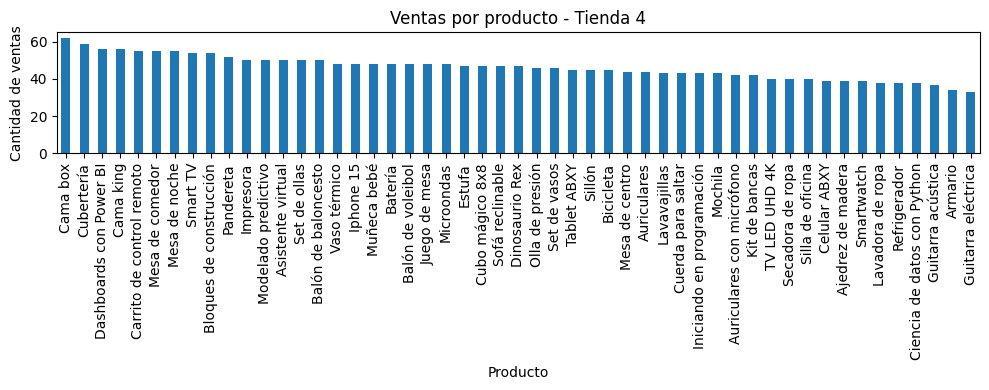

In [22]:
resumen_productos(tienda, "Tienda 1")
resumen_productos(tienda2, "Tienda 2")
resumen_productos(tienda3, "Tienda 3")
resumen_productos(tienda4, "Tienda 4")

# 5. Envío promedio por tienda

In [18]:
envio_prom = {
    "Tienda 1": tienda["Costo de envío"].mean(),
    "Tienda 2": tienda2["Costo de envío"].mean(),
    "Tienda 3": tienda3["Costo de envío"].mean(),
    "Tienda 4": tienda4["Costo de envío"].mean()
}

In [19]:
envio_prom

{'Tienda 1': np.float64(26018.60958033065),
 'Tienda 2': np.float64(25216.235693090293),
 'Tienda 3': np.float64(24805.680373039424),
 'Tienda 4': np.float64(23459.457167090754)}

## Generando gráfico

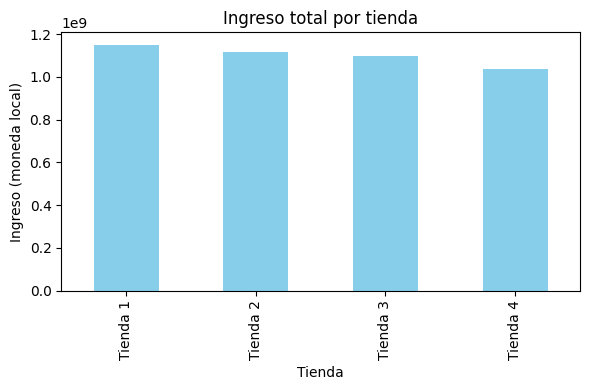

In [23]:
import matplotlib.pyplot as plt

ingresos = {
    "Tienda 1": tienda["Precio"].sum(),
    "Tienda 2": tienda2["Precio"].sum(),
    "Tienda 3": tienda3["Precio"].sum(),
    "Tienda 4": tienda4["Precio"].sum()
}

series_ingresos = pd.Series(ingresos)

series_ingresos.plot(kind="bar", figsize=(6,4), color="skyblue")
plt.title("Ingreso total por tienda")
plt.xlabel("Tienda")
plt.ylabel("Ingreso (moneda local)")
plt.tight_layout()
plt.show()


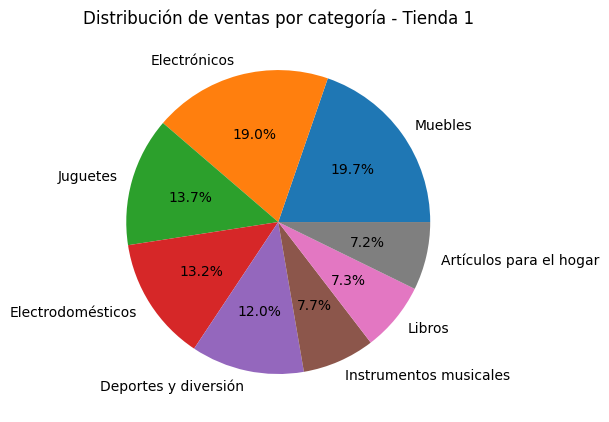

In [24]:
ventas_cat_t1 = (
    tienda.groupby("Categoría del Producto")["Producto"]
    .count()
    .sort_values(ascending=False)
)

ventas_cat_t1.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
plt.title("Distribución de ventas por categoría - Tienda 1")
plt.ylabel("")  # para que no aparezca el texto de eje
plt.tight_layout()
plt.show()


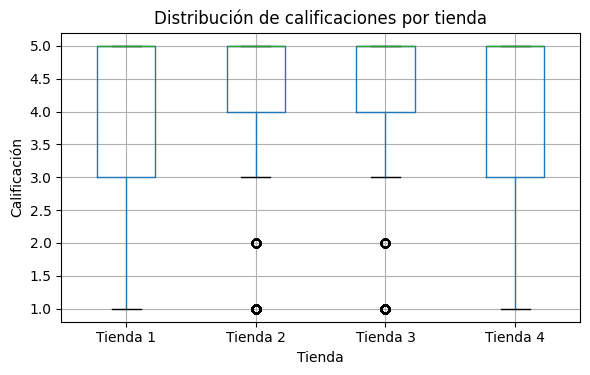

In [25]:
# Unir calificaciones en un solo DataFrame
calif_t1 = tienda[["Calificación"]].copy()
calif_t1["Tienda"] = "Tienda 1"

calif_t2 = tienda2[["Calificación"]].copy()
calif_t2["Tienda"] = "Tienda 2"

calif_t3 = tienda3[["Calificación"]].copy()
calif_t3["Tienda"] = "Tienda 3"

calif_t4 = tienda4[["Calificación"]].copy()
calif_t4["Tienda"] = "Tienda 4"

calif_total = pd.concat([calif_t1, calif_t2, calif_t3, calif_t4], ignore_index=True)

calif_total.boxplot(column="Calificación", by="Tienda", figsize=(6,4))
plt.title("Distribución de calificaciones por tienda")
plt.suptitle("")  # elimina el título extra de pandas
plt.xlabel("Tienda")
plt.ylabel("Calificación")
plt.tight_layout()
plt.show()


## Informe final

Con los datos analizados, la tienda con mayores ingresos es la Tienda 1 (1.150.880.400), seguida muy de cerca por la Tienda 2 y la Tienda 3, mientras que la Tienda 4 presenta el menor ingreso total. En todas las tiendas, las categorías más vendidas son Muebles y Electrónicos, lo que indica una alta demanda en estos segmentos; Juguetes y Electrodomésticos también tienen buena participación, mientras que Libros, Artículos para el hogar e Instrumentos musicales muestran volúmenes menores.

En cuanto a la satisfacción de clientes, las mejores calificaciones promedio las tienen la Tienda 3 (4,05) y la Tienda 2 (4,04), seguidas por la Tienda 4 (4,00) y la Tienda 1 (3,98). Es decir, todas tienen buen nivel, pero Tienda 2 y Tienda 3 destacan ligeramente. Los análisis de productos más y menos vendidos muestran que cada tienda tiene algunos productos “estrella” con alto volumen, y otros con pocas ventas, lo que el Sr. Juan puede usar para alinear su oferta con los artículos que ya tienen buena salida.

Considerando el conjunto de factores de alto nivel de ingresos, fuerte demanda en categorías clave y mejores calificaciones promedio, la recomendación es que el Sr. Juan venda principalmente en la Tienda 3. Esta tienda combina buen volumen de ventas con la mejor satisfacción de clientes, lo que aumenta las probabilidades de rotación y de una experiencia positiva para los compradores. Si los costos de envío de la Tienda 3 son similares a los de las demás, se refuerza aún más esta elección.